<a href="https://colab.research.google.com/github/qjasrubang01-design/CPE-311-Github-Repository-for-Data-Science-1/blob/main/HOA4_1_Supple_FSL_Alphabet_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#FILIPINO SIGN LANGUAGE ALPHABET CLASSIFICATION

##Import

In [170]:
import zipfile
import os
from torchvision import datasets, transforms
from torch.utils.data import random_split, Dataset
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from torchvision.transforms import Lambda
from torch import nn
import torch.nn.functional as F

##Loading Data

In [171]:
zip_path = "/content/archive (4).zip" #https://www.kaggle.com/datasets/japorton/fsl-dataset?resource=download&select=Collated
extract_path = "data/my_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

##Transform

In [172]:
image_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

num_classes = 26
target_transform = Lambda(lambda y: torch.zeros(num_classes, dtype=torch.float).scatter_(0, torch.tensor(y), value=1))

data = datasets.ImageFolder(
    root="/content/data/my_dataset/Collated",
    transform=image_transform,
    target_transform=target_transform
)

print("Classes:", data.classes)
print("Number of images:", len(data))

Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Number of images: 11700


In [173]:
target_transform = Lambda(lambda y: torch.zeros(
    10, dtype=torch.float).scatter_(dim=0, index=torch.tensor(y), value=1))

##Split: Train & Test

In [174]:
train_size = int(0.9 * len(data))
test_size = len(data) - train_size

train_data, test_data = random_split(data, [train_size, test_size])
print("Training data size:", len(train_data))
print("Testing data size:", len(test_data))

Training data size: 10530
Testing data size: 1170


##Visualize

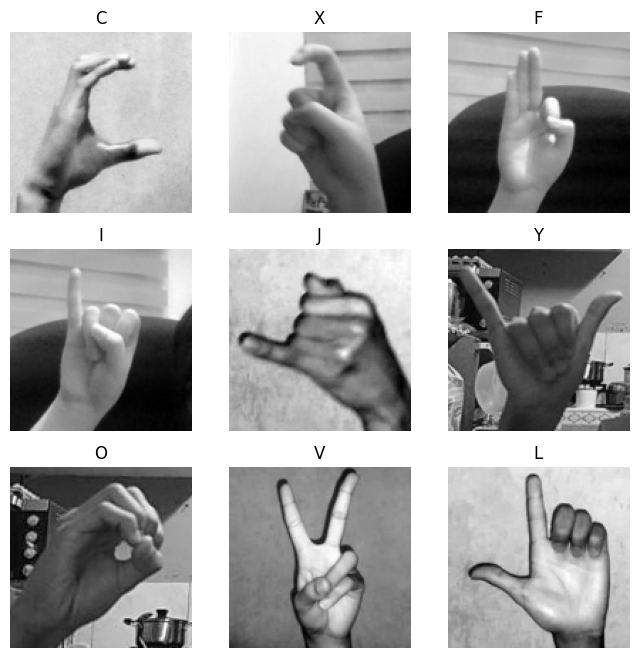

In [175]:
labels_map = {0: "A", 1: "B", 2: "C", 3: "D", 4: "E", 5: "F", 6: "G", 7: "H", 8: "I", 9: "J", 10: "K", 11: "L", 12: "M", 13: "N", 14: "O", 15: "P", 16: "Q", 17: "R", 18: "S", 19: "T", 20: "U", 21: "V", 22: "W", 23: "X", 24: "Y", 25: "Z"
}

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_data), size=(1,)).item()
    img, label = train_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[torch.argmax(label).item()])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [182]:
train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=32, shuffle=True)

Feature batch shape: torch.Size([32, 1, 128, 128])
Labels batch shape: torch.Size([32, 26])


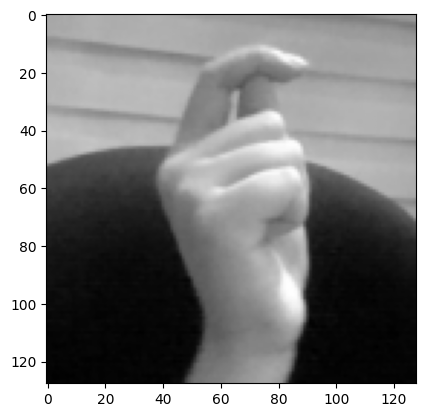

Label: T


In [183]:
# Display image and label.
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {labels_map[torch.argmax(label).item()]}")

##Building Model

In [184]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(128*128, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

In [185]:
model = NeuralNetwork()
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=16384, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=26, bias=True)
  )
)


##Training and Testing Model

In [186]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


def test_loop(dataloader, model, loss_fn):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y.argmax(1)).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [190]:
loss_fn = nn.CrossEntropyLoss()
learning_rate = 1e-3
batch_size = 64
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loop(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 3.100538  [   32/10530]
loss: 3.171419  [ 6432/10530]
loss: 2.987308  [12832/10530]
loss: 2.901146  [19232/10530]
Test Error: 
 Accuracy: 16.0%, Avg loss: 2.767245 

Epoch 2
-------------------------------
loss: 3.023273  [   32/10530]
loss: 2.839252  [ 6432/10530]
loss: 2.609379  [12832/10530]
loss: 2.822236  [19232/10530]
Test Error: 
 Accuracy: 15.4%, Avg loss: 2.675496 

Epoch 3
-------------------------------
loss: 2.502228  [   32/10530]
loss: 2.456481  [ 6432/10530]
loss: 2.257446  [12832/10530]
loss: 1.960238  [19232/10530]
Test Error: 
 Accuracy: 25.4%, Avg loss: 2.370622 

Epoch 4
-------------------------------
loss: 2.248210  [   32/10530]
loss: 2.227535  [ 6432/10530]
loss: 2.028591  [12832/10530]
loss: 2.044632  [19232/10530]
Test Error: 
 Accuracy: 30.6%, Avg loss: 2.247751 

Epoch 5
-------------------------------
loss: 2.321570  [   32/10530]
loss: 2.087345  [ 6432/10530]
loss: 1.898158  [12832/10530]
loss: 1.842262  [19232

##Save and Load Model

In [192]:
torch.save(model.state_dict(), 'model_weights.pth')
model2 = torch.load('model_weights.pth', weights_only=False)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=16384, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=26, bias=True)
  )
)
